# 05 — The Diagnostic Admission Problem

20.1% of all kidney stone admissions are for diagnostic imaging only —
patients admitted for a urography or CT, not for treatment.
Some hospitals admit 90%+ of their kidney stone patients just for imaging.

**Sources FINDINGS.md**: Section 3b (Diagnostic Admissions)

In [1]:
import sys; sys.path.insert(0, ".")
from shared import *
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

kidney = load_kidney()
recent = kidney[kidney["year"] >= 2022].copy()

tags = pd.read_parquet(DATA_DIR / "hospital_tags.parquet")
recent = recent.merge(tags[["CNES", "broad_type", "admission_profile"]],
                      on="CNES", how="left")
recent["broad_type"] = recent["broad_type"].fillna("unknown")

diag = recent[recent["proc_category"] == "DIAGNOSTIC"]

print(f"Diagnostic admissions (2022+): {len(diag):,} of {len(recent):,} ({len(diag)/len(recent)*100:.1f}%)")
print(f"Total bed-days: {diag['DIAS_PERM'].sum():,.0f}")
print(f"Total cost: R$ {diag['VAL_TOT'].sum():,.0f}")
print(f"ER rate: {diag['is_emergency'].mean()*100:.1f}%")

Diagnostic admissions (2022+): 18,078 of 108,697 (16.6%)
Total bed-days: 48,931
Total cost: R$ 7,108,214
ER rate: 94.2%


## LOS distribution for diagnostic admissions

LOS distribution:
  0 days: 1,486 (8.2%)
  1 days: 5,284 (29.2%)
  2 days: 4,641 (25.7%)
  3 days: 2,512 (13.9%)
  >3 days: 4,155 (23.0%)
  >7 days: 868 (4.8%)


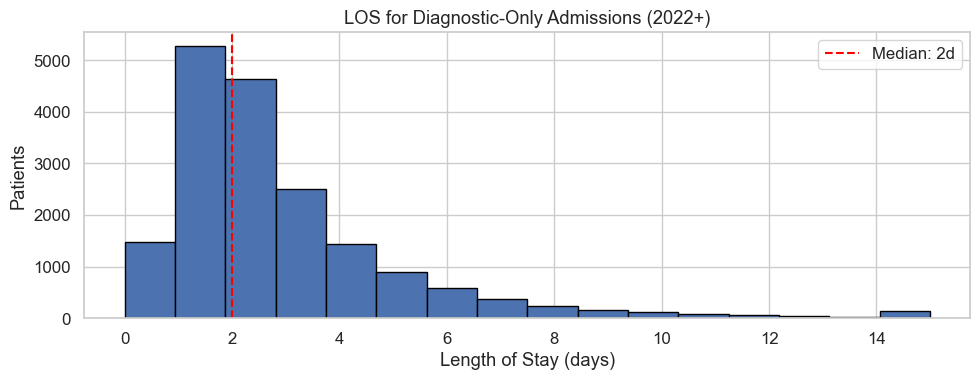

In [2]:
print("LOS distribution:")
for days in [0, 1, 2, 3]:
    n = (diag["DIAS_PERM"] == days).sum()
    print(f"  {days} days: {n:,} ({n/len(diag)*100:.1f}%)")
print(f"  >3 days: {(diag['DIAS_PERM'] > 3).sum():,} ({(diag['DIAS_PERM'] > 3).mean()*100:.1f}%)")
print(f"  >7 days: {(diag['DIAS_PERM'] > 7).sum():,} ({(diag['DIAS_PERM'] > 7).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
diag["DIAS_PERM"].clip(upper=15).hist(bins=16, ax=ax, edgecolor="black")
ax.axvline(diag["DIAS_PERM"].median(), color="red", linestyle="--", label=f"Median: {diag['DIAS_PERM'].median():.0f}d")
ax.set_xlabel("Length of Stay (days)")
ax.set_ylabel("Patients")
ax.set_title("LOS for Diagnostic-Only Admissions (2022+)")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_diagnostic_los.png", dpi=150, bbox_inches="tight")
plt.show()

## Diagnostic-only hospitals (no surgical capability)

In [3]:
cnes_type_map = tags.set_index("CNES")["broad_type"].to_dict()

hosp = recent.groupby("CNES").agg(
    n_total=("DIAG_PRINC", "count"),
    n_diag=("proc_category", lambda x: (x == "DIAGNOSTIC").sum()),
    n_surg=("proc_category", lambda x: (x == "SURGICAL").sum()),
    avg_los=("DIAS_PERM", "mean"),
    city=("MUNIC_MOV", "first"),
).query("n_total >= 20")
hosp["pct_diag"] = hosp["n_diag"] / hosp["n_total"] * 100
hosp["pct_surg"] = hosp["n_surg"] / hosp["n_total"] * 100
hosp["facility_type"] = hosp.index.map(cnes_type_map).fillna("unknown")

diag_only = hosp[hosp["pct_diag"] > 50].sort_values("pct_diag", ascending=False)

print(f"Hospitals with >50% diagnostic admissions ({len(diag_only)}):")
print(f"\nFacility type breakdown (are these UPAs/ERs or general hospitals?):")
print(diag_only["facility_type"].value_counts().to_string())
print()

for cnes, r in diag_only.iterrows():
    print(f"  CNES {cnes} ({city_name(r['city'])}, {r['facility_type']}): "
          f"{r['n_total']:.0f} patients | "
          f"Diagnostic: {r['pct_diag']:.0f}% | Surgical: {r['pct_surg']:.0f}% | LOS {r['avg_los']:.1f}d")

Hospitals with >50% diagnostic admissions (95):

Facility type breakdown (are these UPAs/ERs or general hospitals?):
facility_type
hospital_geral            92
pronto_socorro             2
hospital_especializado     1

  CNES 2082667 (353140, hospital_geral): 63 patients | Diagnostic: 100% | Surgical: 0% | LOS 2.8d
  CNES 2078538 (352400, hospital_geral): 61 patients | Diagnostic: 100% | Surgical: 0% | LOS 2.2d
  CNES 2791684 (350880, hospital_geral): 34 patients | Diagnostic: 100% | Surgical: 0% | LOS 2.7d
  CNES 2785188 (355280, hospital_geral): 45 patients | Diagnostic: 100% | Surgical: 0% | LOS 2.3d
  CNES 2751046 (354770, hospital_geral): 58 patients | Diagnostic: 100% | Surgical: 0% | LOS 2.8d
  CNES 2747871 (352040, hospital_geral): 46 patients | Diagnostic: 100% | Surgical: 0% | LOS 2.0d
  CNES 2083272 (350635, hospital_geral): 32 patients | Diagnostic: 100% | Surgical: 0% | LOS 3.4d
  CNES 2083140 (354680, hospital_geral): 20 patients | Diagnostic: 100% | Surgical: 0% | LOS 8.

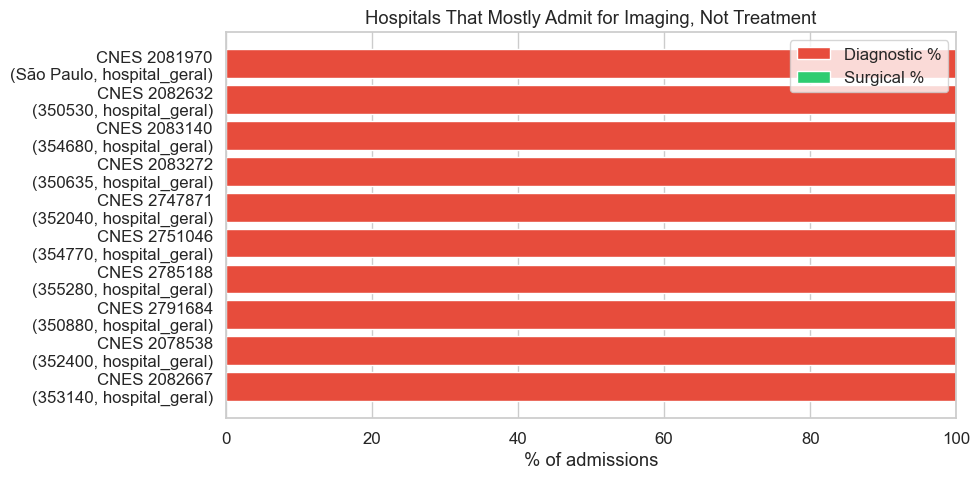

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
top_diag = diag_only.head(10).copy()
top_diag["label"] = [f"CNES {c}\n({city_name(r['city'])}, {r['facility_type']})" for c, r in top_diag.iterrows()]
ax.barh(top_diag["label"], top_diag["pct_diag"], color="#e74c3c", label="Diagnostic %")
ax.barh(top_diag["label"], top_diag["pct_surg"], left=top_diag["pct_diag"], color="#2ecc71", label="Surgical %")
ax.set_xlabel("% of admissions")
ax.set_title("Hospitals That Mostly Admit for Imaging, Not Treatment")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_diagnostic_hospitals.png", dpi=150, bbox_inches="tight")
plt.show()

## Case studies: Marília and Guarulhos

In [5]:
for city_code, name in [("352940", "Marília"), ("352310", "Guarulhos")]:
    city_data = recent[recent["MUNIC_MOV"] == city_code]
    print(f"\n=== {name} ===")
    print(f"Total patients: {len(city_data)}")
    print(f"Diagnostic: {(city_data['proc_category']=='DIAGNOSTIC').mean()*100:.1f}%")
    print(f"Surgical: {(city_data['proc_category']=='SURGICAL').mean()*100:.1f}%")
    print(f"Avg LOS: {city_data['DIAS_PERM'].mean():.1f}d")
    print(f"ER rate: {city_data['is_emergency'].mean()*100:.1f}%")


=== Marília ===
Total patients: 885
Diagnostic: 61.2%
Surgical: 15.4%
Avg LOS: 3.1d
ER rate: 87.1%



=== Guarulhos ===
Total patients: 237
Diagnostic: 98.3%
Surgical: 0.0%
Avg LOS: 4.2d
ER rate: 100.0%


## Save metrics

In [6]:
metrics = {
    "diagnostic_admissions_2022_plus": len(diag),
    "pct_of_total": round(len(diag) / len(recent) * 100, 1),
    "total_bed_days": int(diag["DIAS_PERM"].sum()),
    "total_cost": round(diag["VAL_TOT"].sum(), 0),
    "er_rate": round(diag["is_emergency"].mean() * 100, 1),
    "pct_stay_gt3d": round((diag["DIAS_PERM"] > 3).mean() * 100, 1),
    "n_diagnostic_only_hospitals": len(diag_only),
}
with open(METRICS_DIR / "diagnostic_problem.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved diagnostic_problem.json")

Saved diagnostic_problem.json
